# Anvil profile evaluation (six runs)

Two OpenAI models across three retrieval modes, on one frozen documentation
corpus, one set of login measurements, and one pilot result.

**Provisional.** Ground truth is still `unreviewed`, so every accuracy number is
tentative. There is **one run per configuration (n=1)**, so no variance is
reported; run-to-run stability claims wait for repeated runs. `silent` and
`not_applicable` are merged into one *expected absence* class. String matches are
case-insensitive; numeric and Boolean matches are typed; `set` matches ignore order.


In [1]:
from collections import Counter
from hashlib import sha256
from pathlib import Path
import json
import re

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Run the notebook from inside the HPC Site Preflight repository.")


ROOT = find_repo_root(Path.cwd().resolve())
RESULT_ROOT = ROOT / "artifacts/evaluation/anvil"
GROUND_TRUTH_PATH = ROOT / "evaluation/ground-truth/partial-anvil-site-profile.csv"
CORPUS_DIR = ROOT / "examples/simulate/anvil/corpus"
MEASUREMENTS_PATH = ROOT / "examples/simulate/anvil/login-measurements.json"
PILOT_PATH = ROOT / "examples/simulate/anvil/pilot-result.json"
ANALYSIS_DIR = RESULT_ROOT / "preliminary-analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

MODELS = {
    "gpt-5-mini": "GPT-5 Mini",
    "gpt-5.6-terra": "GPT-5.6 Terra",
}
MODES = {
    "full-corpus": "Full corpus",
    "bm25": "BM25",
    "llm-expanded-bm25": "LLM-expanded BM25",
}
RUN_ORDER = [(model, mode) for model in MODELS for mode in MODES]

# --- paper figure style (IEEE: single col ~3.4in, double col ~7.0in) ---
COL_1, COL_2 = 3.4, 7.0
MODEL_COLORS = {"GPT-5 Mini": "#4C78A8", "GPT-5.6 Terra": "#F58518"}
MODE_COLORS = {"Full corpus": "#4C78A8", "BM25": "#54A24B", "LLM-expanded BM25": "#F58518"}

plt.rcParams.update({
    "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 8,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "figure.dpi": 150, "savefig.dpi": 300,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
})

PROVISIONAL = "n=1 per config; provisional ground truth"


def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def file_hash(path: Path) -> str:
    return sha256(path.read_bytes()).hexdigest()


def save(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(ANALYSIS_DIR / f"{name}.{ext}", bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(ANALYSIS_DIR / f"{name}.png")))


print(f"Repository: {ROOT}")
print(f"Analysis output: {ANALYSIS_DIR}")


Repository: /Users/saiful/ai-projects/hpc-site-preflight
Analysis output: /Users/saiful/ai-projects/hpc-site-preflight/artifacts/evaluation/anvil/preliminary-analysis


## 1. Load and verify the six runs

Each run must be completed, share the same frozen corpus fingerprint and pilot
result, and make no web tool calls. Where a run directory holds several attempts,
the most recently started performance record is used.


In [2]:
def load_runs() -> dict:
    loaded = {}
    for model, mode in RUN_ORDER:
        base = RESULT_ROOT / model / mode / "run-01"
        output = base / "output"
        performance_paths = list((base / "runs").glob("*/performance.json"))
        if not performance_paths:
            raise FileNotFoundError(f"No performance result for {model} / {mode}")
        performance = max((read_json(p) for p in performance_paths),
                          key=lambda item: item["started_at"])
        loaded[(model, mode)] = {
            "performance": performance,
            "profile": read_json(output / "site-profile.json"),
            "documentation": read_json(output / "documentation-evidence.json"),
            "evidence": read_json(output / "evidence-report.json"),
            "pilot": read_json(output / "pilot-evidence.json"),
        }
    return loaded


runs = load_runs()

integrity = pd.DataFrame([
    {
        "model": MODELS[model], "mode": MODES[mode],
        "run_id": run["performance"]["run_id"],
        "status": run["performance"]["status"],
        "corpus_fingerprint": run["documentation"]["corpus_fingerprint"],
        "pilot_id": run["pilot"]["pilot_id"],
        "site_id": run["profile"]["site_id"],
        "web_tool_calls": run["performance"]["tool_calls"],
    }
    for (model, mode), run in runs.items()
])
display(integrity)

assert set(integrity["status"]) == {"completed"}
assert integrity["corpus_fingerprint"].nunique() == 1
assert integrity["pilot_id"].nunique() == 1
assert integrity["site_id"].nunique() == 1
assert set(integrity["web_tool_calls"]) == {0}

input_hashes = pd.DataFrame([
    {"input": "login measurements", "sha256": file_hash(MEASUREMENTS_PATH)},
    {"input": "pilot result", "sha256": file_hash(PILOT_PATH)},
    {"input": "corpus manifest", "sha256": file_hash(CORPUS_DIR / "manifest.json")},
    {"input": "corpus documents", "sha256": file_hash(CORPUS_DIR / "documents.jsonl")},
    {"input": "corpus chunks", "sha256": file_hash(CORPUS_DIR / "chunks.jsonl")},
])
display(input_hashes)


,model,mode,run_id,status,corpus_fingerprint,pilot_id,site_id,web_tool_calls
0,GPT-5 Mini,Full corpus,dec0c28b-b5a0-40d7-8f48-bc00dd6173d3,completed,92e269282edacb5fb32b139ae6d55bc539ef886e1edcbb...,7a1036ad15d941149f86297aa2b5379a,anvil,0
1,GPT-5 Mini,BM25,e322117d-c2e6-4840-94db-11dd3134ff6c,completed,92e269282edacb5fb32b139ae6d55bc539ef886e1edcbb...,7a1036ad15d941149f86297aa2b5379a,anvil,0
2,GPT-5 Mini,LLM-expanded BM25,dc468d51-79ca-40f0-a3f6-3d798d22488a,completed,92e269282edacb5fb32b139ae6d55bc539ef886e1edcbb...,7a1036ad15d941149f86297aa2b5379a,anvil,0
3,GPT-5.6 Terra,Full corpus,d510f42b-ff2e-4c17-a33a-6845392bf63b,completed,92e269282edacb5fb32b139ae6d55bc539ef886e1edcbb...,7a1036ad15d941149f86297aa2b5379a,anvil,0
4,GPT-5.6 Terra,BM25,d14b7af7-d727-420f-9a8d-0508582b06e7,completed,92e269282edacb5fb32b139ae6d55bc539ef886e1edcbb...,7a1036ad15d941149f86297aa2b5379a,anvil,0
5,GPT-5.6 Terra,LLM-expanded BM25,f5672f54-271f-4ac9-a12f-5c482f3ae63d,completed,92e269282edacb5fb32b139ae6d55bc539ef886e1edcbb...,7a1036ad15d941149f86297aa2b5379a,anvil,0


,input,sha256
0,login measurements,d6b72c003c16996ca88d9ead54d0d58662b945836ff993...
1,pilot result,886132649cc61567e78306b47b5313b596880532a9a100...
2,corpus manifest,9096b93688785ca57490afaafdf50dc7f749ebcde7dcb6...
3,corpus documents,e7195defd42eff945e86ceaa1114fa03cd4f51e86208b0...
4,corpus chunks,8ed81f7b59d075ae61197d56aa2b3324222d66e62f1314...


## 2. Cost

Provider-reported tokens are used directly. Model latency sums the
`structured_model_call` stage durations; total latency covers the whole build.
Latency is reported in a table, not plotted: across web fetches and the queue it
is dominated by network noise, and at n=1 a bar would imply a precision we do not
have. Tokens and model-call counts are the stable cost signals.


In [3]:
performance_rows = []
for (model, mode), run in runs.items():
    perf = run["performance"]
    usage = perf["model_usage"]
    model_seconds = sum(
        step["duration_seconds"] for step in perf["steps"]
        if step["name"] == "structured_model_call"
    )
    performance_rows.append({
        "model": MODELS[model], "mode": MODES[mode], "run_id": perf["run_id"],
        "total_seconds": perf["duration_seconds"], "model_seconds": model_seconds,
        "model_calls": usage["requests"],
        "input_tokens": usage["input_tokens"], "output_tokens": usage["output_tokens"],
        "total_tokens": usage["total_tokens"], "retries": perf["retries"],
    })

performance_df = pd.DataFrame(performance_rows)
performance_df["model"] = pd.Categorical(performance_df["model"], list(MODELS.values()), ordered=True)
performance_df["mode"] = pd.Categorical(performance_df["mode"], list(MODES.values()), ordered=True)
performance_df = performance_df.sort_values(["model", "mode"]).reset_index(drop=True)
performance_df.to_csv(ANALYSIS_DIR / "run-summary.csv", index=False)

labels = [f"{r.model.replace('GPT-5','').strip()}\n{r.mode}" for r in performance_df.itertuples()]
display(performance_df)


,model,mode,run_id,total_seconds,model_seconds,model_calls,input_tokens,output_tokens,total_tokens,retries
0,GPT-5 Mini,Full corpus,dec0c28b-b5a0-40d7-8f48-bc00dd6173d3,594.417469,594.203137,13,53923,39612,93535,0
1,GPT-5 Mini,BM25,e322117d-c2e6-4840-94db-11dd3134ff6c,173.140333,172.838170,5,11902,13168,25070,0
2,GPT-5 Mini,LLM-expanded BM25,dc468d51-79ca-40f0-a3f6-3d798d22488a,174.151425,173.675802,6,16787,10584,27371,0
3,GPT-5.6 Terra,Full corpus,d510f42b-ff2e-4c17-a33a-6845392bf63b,46.600143,46.390329,14,58084,3513,61597,0
4,GPT-5.6 Terra,BM25,d14b7af7-d727-420f-9a8d-0508582b06e7,18.789626,18.547669,4,8822,1700,10522,0
5,GPT-5.6 Terra,LLM-expanded BM25,f5672f54-271f-4ac9-a12f-5c482f3ae63d,19.911615,19.510458,4,9391,1687,11078,0


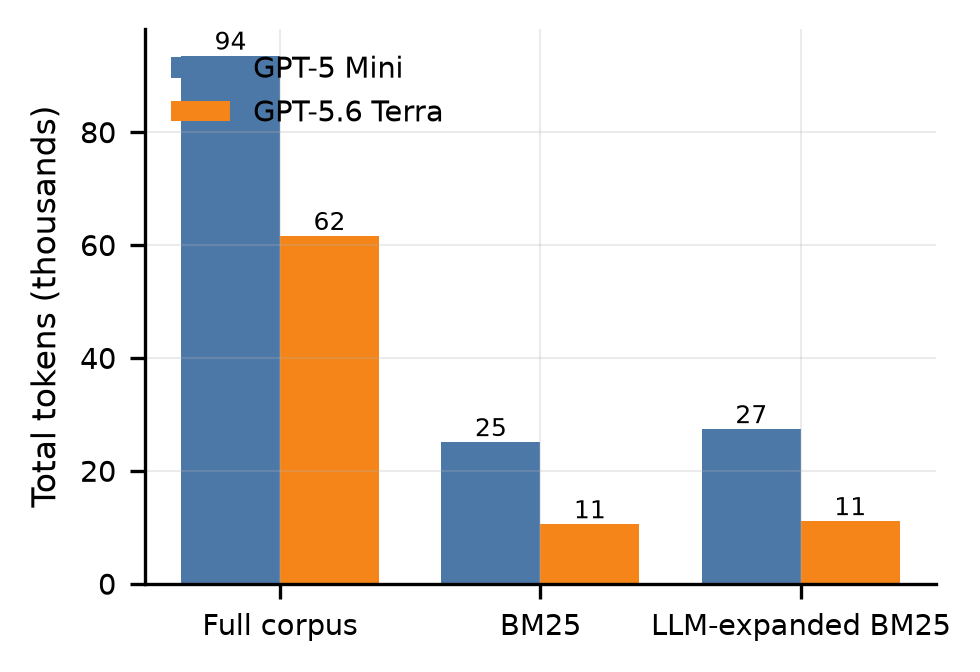

In [4]:
fig, ax = plt.subplots(figsize=(COL_1, 2.4))
modes = list(MODES.values())
models = list(MODELS.values())
w = 0.38
xpos = list(range(len(modes)))
for k, mdl in enumerate(models):
    sub = performance_df[performance_df["model"] == mdl].set_index("mode")
    tot = [sub.loc[m, "total_tokens"] / 1000 for m in modes]
    off = (k - (len(models) - 1) / 2) * w
    bars = ax.bar([x + off for x in xpos], tot, w, label=mdl, color=MODEL_COLORS[mdl])
    for b, v in zip(bars, tot):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.0f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(xpos, modes)
ax.set_ylabel("Total tokens (thousands)")
ax.legend(frameon=False, loc="upper left")
save(fig, "token-usage")


In [5]:
perf_table = (performance_df
    .assign(**{"tokens (k)": (performance_df["total_tokens"] / 1000).round(1)})
    [["model", "mode", "model_calls", "tokens (k)", "total_seconds", "model_seconds", "retries"]]
    .rename(columns={"total_seconds": "total (s)", "model_seconds": "model (s)"}))
perf_table.to_csv(ANALYSIS_DIR / "performance-table.csv", index=False)
display(perf_table)
print("Latency is reported here, not plotted: it is network- and queue-dominated "
      "and needs repeated runs before any bar is meaningful.")


,model,mode,model_calls,tokens (k),total (s),model (s),retries
0,GPT-5 Mini,Full corpus,13,93.5,594.417469,594.203137,0
1,GPT-5 Mini,BM25,5,25.1,173.140333,172.838170,0
2,GPT-5 Mini,LLM-expanded BM25,6,27.4,174.151425,173.675802,0
3,GPT-5.6 Terra,Full corpus,14,61.6,46.600143,46.390329,0
4,GPT-5.6 Terra,BM25,4,10.5,18.789626,18.547669,0
5,GPT-5.6 Terra,LLM-expanded BM25,4,11.1,19.911615,19.510458,0


Latency is reported here, not plotted: it is network- and queue-dominated and needs repeated runs before any bar is meaningful.


## 3. Provisional field evaluation

Named profile arrays become addressable paths before comparison; the `account`
element of `slurm.options` becomes `/slurm/options/account/...`.

Outcomes: **correct value** (populated, matches); **incorrect value** (populated,
disagrees); **missing value** (expected, but abstained); **correct absence**
(expected `silent`/`not_applicable`, and absent); **unexpected value** (expected
absence, but populated). Incorrect values count against both precision and recall.


In [6]:
MISSING = object()


def named(items, key="name"):
    return {item[key]: item for item in items or []}


def flatten_profile(profile: dict) -> dict:
    values = {
        "/aliases": profile.get("aliases"),
        "/scheduler_type": profile.get("scheduler_type"),
        "/scheduler_version": profile.get("scheduler_version"),
        "/htcondor": profile.get("htcondor"),
    }
    slurm = profile.get("slurm") or {}
    options = named(slurm.get("options", []))
    partitions = named(slurm.get("partitions", []))
    values["/slurm/submit_command"] = slurm.get("submit_command")
    values["/slurm/options"] = list(options)
    values["/slurm/unmapped_options"] = slurm.get("unmapped_options", [])
    for option_name, option in options.items():
        for field in ("syntax", "required", "allowed_values"):
            values[f"/slurm/options/{option_name}/{field}"] = option.get(field)
    values["/slurm/partitions"] = list(partitions)
    for partition_name, partition in partitions.items():
        for field in ("available", "maximum_walltime_seconds",
                      "node_count", "cpus_per_node", "memory_mib_per_node",
                      "temporary_disk_mib_per_node", "gpu_count_per_node",
                      "gpu_models", "features"):
            values[f"/slurm/partitions/{partition_name}/{field}"] = partition.get(field)

    storage = named(profile.get("storage", []))
    values["/storage"] = list(storage)
    for storage_name, item in storage.items():
        for field in ("path_pattern", "filesystem_type", "login_readable", "login_writable",
                      "compute_visible", "compute_readable", "compute_writable",
                      "available_bytes", "purge_after_days"):
            values[f"/storage/{storage_name}/{field}"] = item.get(field)

    network = profile.get("network", {})
    for section in ("login", "compute", "login_compute", "compute_compute"):
        for field, value in network.get(section, {}).items():
            values[f"/network/{section}/{field}"] = value

    for section in ("accounting", "software"):
        for field, value in profile.get(section, {}).items():
            values[f"/{section}/{field}"] = value
    return values


def parse_json_cell(value):
    if pd.isna(value) or str(value).strip() == "":
        return MISSING
    return json.loads(str(value))


def normalize(value):
    if isinstance(value, str):
        return re.sub(r"\s+", " ", value).strip().casefold()
    if isinstance(value, list):
        return [normalize(item) for item in value]
    if isinstance(value, dict):
        return {k.casefold(): normalize(v) for k, v in sorted(value.items())}
    return value


def is_absent(value) -> bool:
    return value is MISSING or value is None or value == "" or value == [] or value == {}


def values_match(actual, expected, rule: str) -> bool:
    actual, expected = normalize(actual), normalize(expected)
    if rule == "set":
        if not isinstance(actual, list) or not isinstance(expected, list):
            return False
        enc = lambda item: json.dumps(item, sort_keys=True, ensure_ascii=False)
        return {enc(i) for i in actual} == {enc(i) for i in expected}
    return actual == expected


def render_value(value) -> str:
    return "" if value is MISSING else json.dumps(value, ensure_ascii=False, sort_keys=True)


truth = pd.read_csv(GROUND_TRUTH_PATH, dtype=str, keep_default_na=False)
truth["expected_class"] = truth["expected_state"].map(
    lambda state: "value" if state == "value" else "absence")
print("Ground-truth rows:", len(truth))
print("Review status:", truth["review_status"].value_counts().to_dict())
print("Expected classes:", truth["expected_class"].value_counts().to_dict())


Ground-truth rows: 191
Review status: {'unreviewed': 191}
Expected classes: {'value': 111, 'absence': 80}


In [7]:
field_rows, metric_rows = [], []
for model, mode in RUN_ORDER:
    actual = flatten_profile(runs[(model, mode)]["profile"])
    outcomes = Counter()
    for row in truth.to_dict(orient="records"):
        expected = parse_json_cell(row["expected_value_json"])
        observed = actual.get(row["field_path"], MISSING)
        if row["expected_class"] == "absence":
            outcome = "correct_absence" if is_absent(observed) else "unexpected_value"
        elif is_absent(observed):
            outcome = "missing_value"
        elif values_match(observed, expected, row["match_rule"]):
            outcome = "correct_value"
        else:
            outcome = "incorrect_value"
        outcomes[outcome] += 1
        field_rows.append({
            "model": MODELS[model], "mode": MODES[mode],
            "field_path": row["field_path"], "section": row["section"],
            "expected_state": row["expected_state"], "expected_class": row["expected_class"],
            "expected_value_json": row["expected_value_json"],
            "actual_value_json": render_value(observed),
            "match_rule": row["match_rule"], "outcome": outcome,
            "review_status": row["review_status"],
        })

    tp = outcomes["correct_value"]
    predicted = tp + outcomes["incorrect_value"] + outcomes["unexpected_value"]
    expected_values = int((truth["expected_class"] == "value").sum())
    expected_absence = int((truth["expected_class"] == "absence").sum())
    precision = tp / predicted if predicted else 0.0
    recall = tp / expected_values if expected_values else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    absence_acc = outcomes["correct_absence"] / expected_absence if expected_absence else 0.0
    field_acc = (outcomes["correct_value"] + outcomes["correct_absence"]) / len(truth)
    metric_rows.append({
        "model": MODELS[model], "mode": MODES[mode], **outcomes,
        "precision": precision, "recall": recall, "f1": f1,
        "abstention_accuracy": absence_acc, "field_accuracy": field_acc,
    })

field_df = pd.DataFrame(field_rows)
metrics_df = pd.DataFrame(metric_rows)
for outcome in ("correct_value", "incorrect_value", "missing_value",
                "correct_absence", "unexpected_value"):
    if outcome not in metrics_df:
        metrics_df[outcome] = 0
    metrics_df[outcome] = metrics_df[outcome].fillna(0).astype(int)
metrics_df["model"] = pd.Categorical(metrics_df["model"], list(MODELS.values()), ordered=True)
metrics_df["mode"] = pd.Categorical(metrics_df["mode"], list(MODES.values()), ordered=True)
metrics_df = metrics_df.sort_values(["model", "mode"]).reset_index(drop=True)
field_df.to_csv(ANALYSIS_DIR / "field-evaluation.csv", index=False)
metrics_df.to_csv(ANALYSIS_DIR / "mode-metrics.csv", index=False)
display(metrics_df)


,model,mode,missing_value,correct_value,unexpected_value,correct_absence,incorrect_value,precision,recall,f1,abstention_accuracy,field_accuracy
0,GPT-5 Mini,Full corpus,28,81,13,67,2,0.843750,0.729730,0.782609,0.8375,0.774869
1,GPT-5 Mini,BM25,27,83,10,70,1,0.882979,0.747748,0.809756,0.8750,0.801047
2,GPT-5 Mini,LLM-expanded BM25,27,82,13,67,2,0.845361,0.738739,0.788462,0.8375,0.780105
3,GPT-5.6 Terra,Full corpus,28,82,10,70,1,0.881720,0.738739,0.803922,0.8750,0.795812
4,GPT-5.6 Terra,BM25,29,82,9,71,0,0.901099,0.738739,0.811881,0.8875,0.801047
5,GPT-5.6 Terra,LLM-expanded BM25,28,82,9,71,1,0.891304,0.738739,0.807882,0.8875,0.801047


### Does the model axis matter?

Before spending figures on the model comparison, check whether the two models
produce materially different profiles. If they agree on almost every field, the
model axis carries little information and the paper should lead with the mode
axis (which is what RQ2 is about) and put the model comparison in a table.


In [8]:
pivot = field_df.pivot_table(index=["mode", "field_path"], columns="model",
                             values="outcome", aggfunc="first")
disagree = pivot[pivot.iloc[:, 0] != pivot.iloc[:, 1]]
print(f"Field-outcome cells where the two models differ: {len(disagree)} "
      f"of {len(pivot)} (per-mode x field).")
if len(disagree):
    display(disagree.reset_index().head(30))
else:
    print("Models produce identical field outcomes on every path. "
          "Consider collapsing the model axis in the paper.")


Field-outcome cells where the two models differ: 18 of 573 (per-mode x field).


model,mode,field_path,GPT-5 Mini,GPT-5.6 Terra
0,BM25,/network/compute/outbound_https,incorrect_value,missing_value
1,BM25,/network/compute_compute/tcp_connect,correct_value,missing_value
2,BM25,/network/login_compute/tcp_connect,correct_value,missing_value
3,BM25,/slurm/options/partition/required,missing_value,correct_value
4,BM25,/slurm/unmapped_options,unexpected_value,correct_absence
5,Full corpus,/network/compute/outbound_https,incorrect_value,missing_value
6,Full corpus,/network/compute_compute/tcp_connect,missing_value,correct_value
7,Full corpus,/network/login_compute/tcp_connect,missing_value,correct_value
8,Full corpus,/slurm/options/account/required,correct_value,missing_value
9,Full corpus,/slurm/options/cpus-per-task/required,unexpected_value,correct_absence


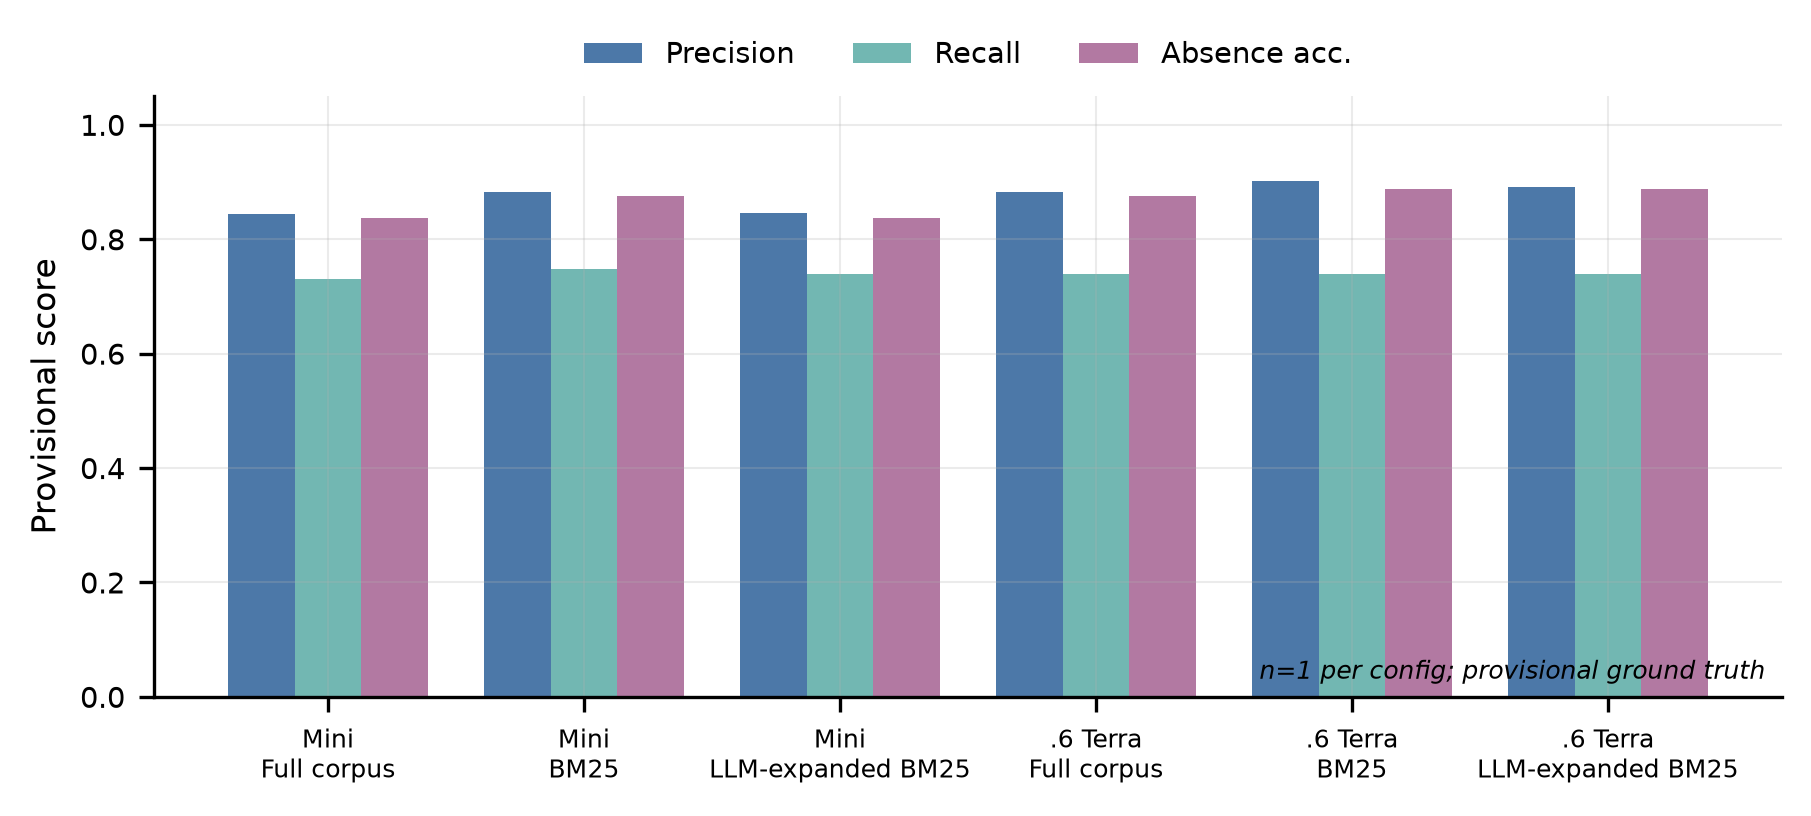

In [9]:
fig, ax = plt.subplots(figsize=(COL_2, 2.6))
metric_names = ["precision", "recall", "abstention_accuracy"]
metric_labels = ["Precision", "Recall", "Absence acc."]
metric_colors = ["#4C78A8", "#72B7B2", "#B279A2"]
groups = [(mdl, mode) for mdl in models for mode in modes]
gw = 0.26
base = list(range(len(groups)))
for j, (m, lab, c) in enumerate(zip(metric_names, metric_labels, metric_colors)):
    vals = [metrics_df[(metrics_df["model"] == mdl) & (metrics_df["mode"] == mode)][m].iloc[0]
            for mdl, mode in groups]
    off = (j - 1) * gw
    ax.bar([b + off for b in base], vals, gw, label=lab, color=c)
ax.set_xticks(base, [f"{mdl.replace('GPT-5','').strip()}\n{mode}" for mdl, mode in groups], fontsize=6)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Provisional score")
ax.legend(frameon=False, ncol=3, loc="lower center", bbox_to_anchor=(0.5, 1.0))
ax.text(0.99, 0.02, PROVISIONAL, transform=ax.transAxes, ha="right", va="bottom",
        fontsize=6, style="italic")
save(fig, "field-metrics")


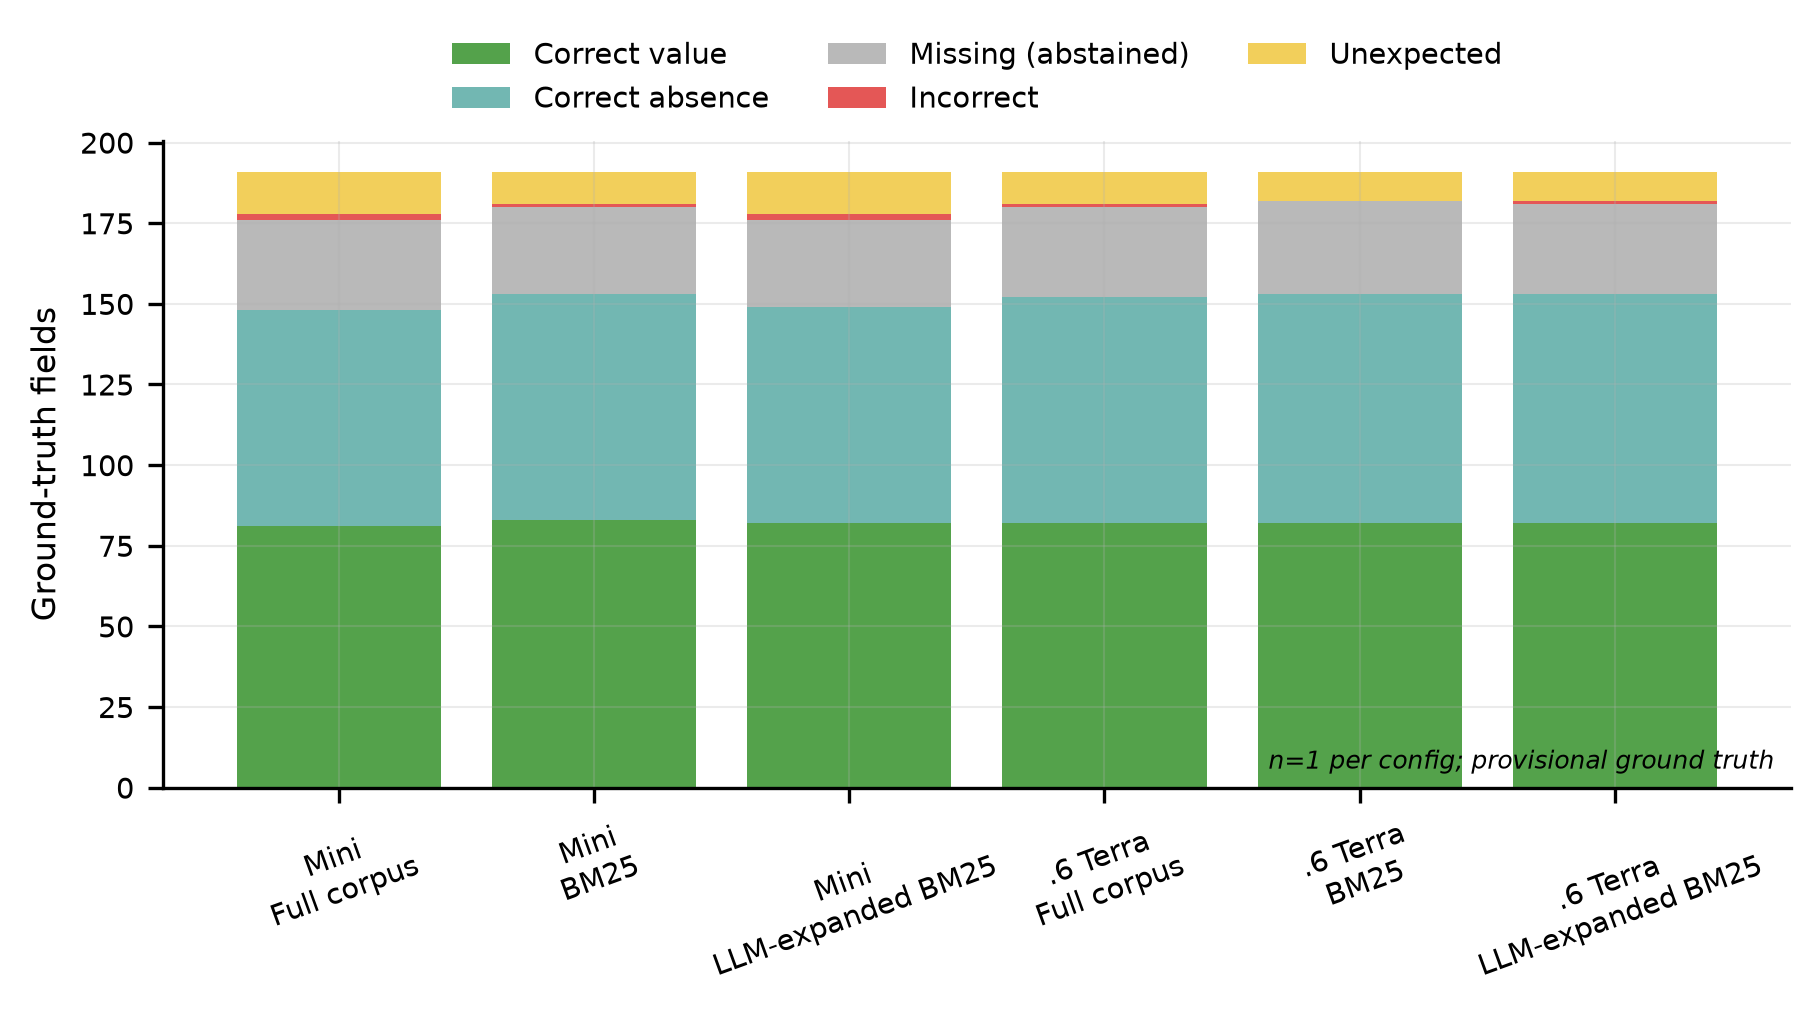

In [10]:
fig, ax = plt.subplots(figsize=(COL_2, 2.8))
outcome_columns = ["correct_value", "correct_absence", "missing_value",
                   "incorrect_value", "unexpected_value"]
outcome_labels = ["Correct value", "Correct absence", "Missing (abstained)",
                  "Incorrect", "Unexpected"]
outcome_colors = ["#54A24B", "#72B7B2", "#B9B9B9", "#E45756", "#F2CF5B"]
bottom = pd.Series([0.0] * len(metrics_df))
for col, lab, c in zip(outcome_columns, outcome_labels, outcome_colors):
    vals = metrics_df.get(col, pd.Series([0] * len(metrics_df))).fillna(0).reset_index(drop=True)
    ax.bar(labels, vals, bottom=bottom, label=lab, color=c)
    bottom = bottom + vals
ax.set_ylabel("Ground-truth fields")
ax.tick_params(axis="x", rotation=20)
ax.legend(frameon=False, ncol=3, loc="lower center", bbox_to_anchor=(0.5, 1.0))
ax.text(0.99, 0.02, PROVISIONAL, transform=ax.transAxes, ha="right", va="bottom",
        fontsize=6, style="italic")
save(fig, "field-outcomes")


## 4. Configuration vs documentation disagreement

The headline finding, made concrete. For each partition, the value the scheduler
reports (measured) is placed beside the value the documentation states
(documented). Where the scheduler is more permissive than the documented policy,
a tool that trusts measurement builds a job the site rejects. This reads straight
from the profile; if the measured side is null everywhere, the serializer is not
carrying it and that is itself a finding to fix before the figure is used.


,partition,measured_h,documented_h
0,wholenode,NaN,96.0
1,standard,NaN,NaN
2,shared,NaN,96.0
3,wide,NaN,12.0
4,highmem,NaN,48.0
5,debug,NaN,2.0
6,gpu,NaN,48.0
7,ai,NaN,48.0
8,gpu-debug,NaN,0.5
9,profiling,NaN,NaN


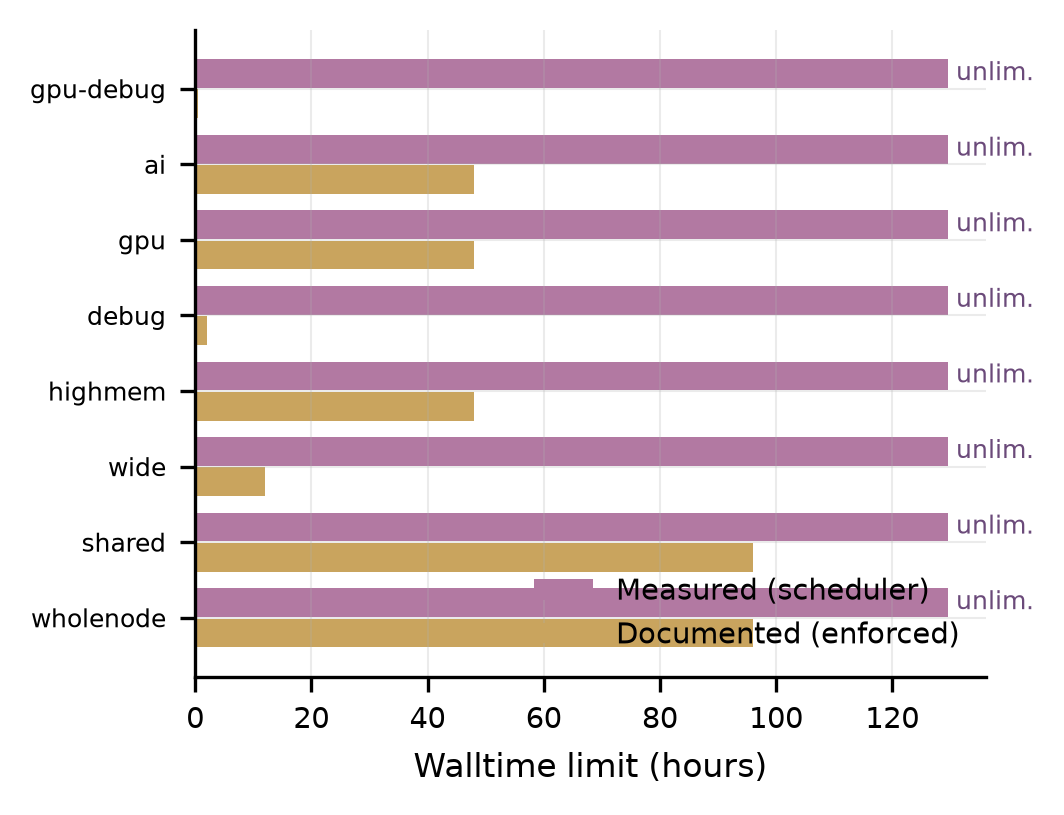

In [11]:
rep = runs[(list(MODELS)[0], "bm25")]["profile"]

rows = []
for conflict in rep.get("conflicts", []):
    if not conflict.get("field", "").endswith("/maximum_walltime_seconds"):
        continue
    values = {item["source"]: item.get("value") for item in conflict.get("evidence_values", [])}
    measured = values.get("measurement")
    documented = values.get("documentation")
    rows.append({
        "partition": conflict["field"].split("/")[-2],
        "measured_h": np.nan if measured == -1 else measured / 3600,
        "documented_h": documented / 3600,
    })
wt = pd.DataFrame(rows, columns=["partition", "measured_h", "documented_h"])
wt.to_csv(ANALYSIS_DIR / "walltime-disagreement.csv", index=False)
display(wt)

documented = wt[wt["documented_h"].notna()].reset_index(drop=True)
if len(documented):
    fig, ax = plt.subplots(figsize=(COL_1, 2.8))
    y = range(len(documented))
    cap = documented["documented_h"].max() * 1.35
    meas = documented["measured_h"].fillna(cap)
    ax.barh([i + 0.2 for i in y], meas, 0.38, color="#B279A2", label="Measured (scheduler)")
    ax.barh([i - 0.2 for i in y], documented["documented_h"], 0.38, color="#C9A45E",
            label="Documented (enforced)")
    for i, v in enumerate(documented["measured_h"]):
        if not np.isfinite(v):
            ax.text(cap, i + 0.2, " unlim.", va="center", fontsize=6, color="#6B4A7A")
    ax.set_yticks(list(y), documented["partition"], fontsize=6)
    ax.set_xlabel("Walltime limit (hours)")
    ax.legend(frameon=False, loc="lower right")
    save(fig, "walltime-disagreement")
else:
    print("No partition carries a documented walltime; nothing to plot. "
          "Check the reconciliation/serializer path.")


## 5. Documentation and citation checks

Mechanical citation validity requires: the cited chunk exists in the frozen
corpus; the cited URL matches the chunk; the chunk is target-site scoped; and the
exact quote occurs in the chunk after whitespace normalization. This does **not**
establish that the quote semantically proves the claim; semantic validity needs
human annotation.


In [12]:
chunks = {
    item["chunk_id"]: item
    for item in (json.loads(line)
                 for line in (CORPUS_DIR / "chunks.jsonl").read_text(encoding="utf-8").splitlines()
                 if line.strip())
}


def normalized_text(value: str) -> str:
    return re.sub(r"\s+", " ", value).strip().casefold()


citation_rows, documentation_rows = [], []
for model, mode in RUN_ORDER:
    documentation = runs[(model, mode)]["documentation"]
    valid_count = citation_count = 0
    for finding_index, finding in enumerate(documentation["findings"]):
        for citation in finding["citations"]:
            citation_count += 1
            chunk = chunks.get(citation["chunk_id"])
            valid = (
                chunk is not None
                and normalized_text(citation["url"]) == normalized_text(chunk["source_url"])
                and chunk["scope"] == "target_site"
                and normalized_text(citation["quote"]) in normalized_text(chunk["text"])
            )
            valid_count += int(valid)
            citation_rows.append({
                "model": MODELS[model], "mode": MODES[mode],
                "finding_index": finding_index, "chunk_id": citation["chunk_id"],
                "url": citation["url"], "quote": citation["quote"],
                "mechanically_valid": valid,
            })
    documentation_rows.append({
        "model": MODELS[model], "mode": MODES[mode],
        "accepted_findings": len(documentation["findings"]),
        "rejected_proposals": len(documentation["rejected"]),
        "unresolved_documentation_fields": len(documentation["unresolved"]),
        "selected_chunks": len(set(documentation["selected_chunk_ids"])),
        "citations": citation_count, "valid_citations": valid_count,
        "mechanical_citation_validity": valid_count / citation_count if citation_count else 0.0,
    })

citation_df = pd.DataFrame(citation_rows)
documentation_df = pd.DataFrame(documentation_rows)
citation_df.to_csv(ANALYSIS_DIR / "citation-checks.csv", index=False)
documentation_df.to_csv(ANALYSIS_DIR / "documentation-summary.csv", index=False)
display(documentation_df)


,model,mode,accepted_findings,rejected_proposals,unresolved_documentation_fields,selected_chunks,citations,valid_citations,mechanical_citation_validity
0,GPT-5 Mini,Full corpus,59,0,1,371,94,94,1.0
1,GPT-5 Mini,BM25,15,5,2,22,33,33,1.0
2,GPT-5 Mini,LLM-expanded BM25,19,3,2,34,33,33,1.0
3,GPT-5.6 Terra,Full corpus,12,1,4,371,22,22,1.0
4,GPT-5.6 Terra,BM25,14,1,2,22,38,38,1.0
5,GPT-5.6 Terra,LLM-expanded BM25,15,0,1,33,25,25,1.0


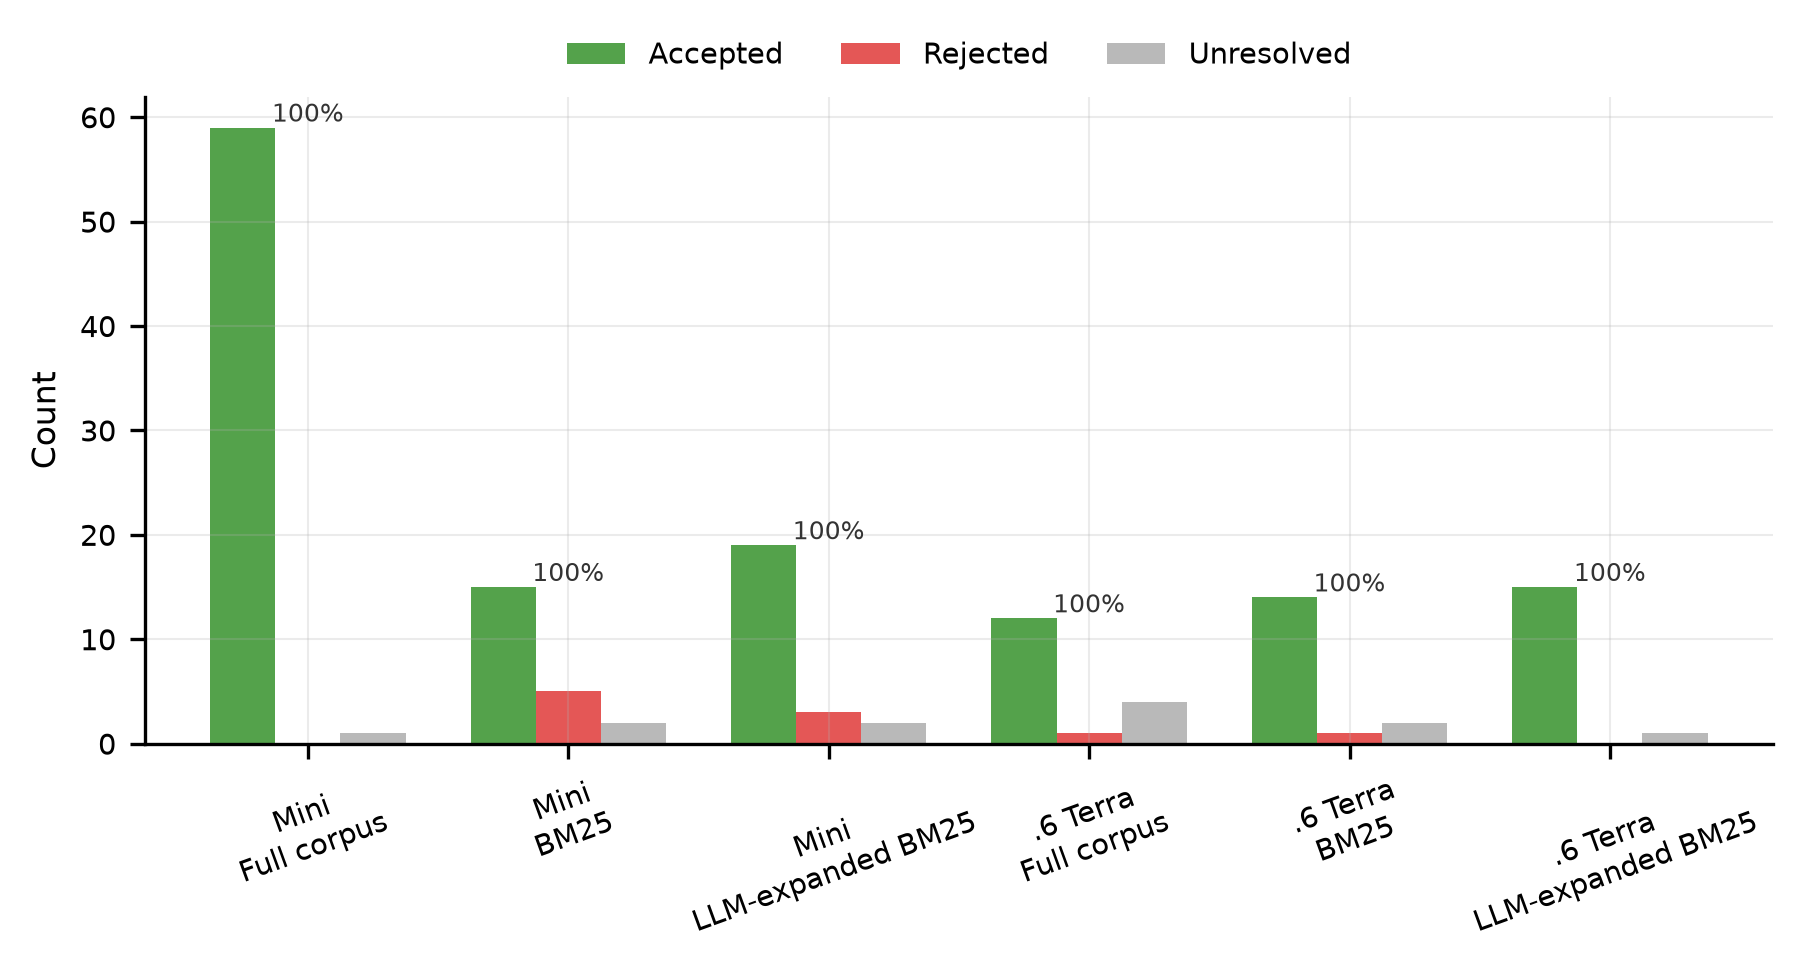

Percentages above bars: mechanical citation validity for that configuration.


In [13]:
fig, ax = plt.subplots(figsize=(COL_2, 2.8))
doc_plot = documentation_df.set_index(["model", "mode"])[
    ["accepted_findings", "rejected_proposals", "unresolved_documentation_fields"]]
doc_plot.index = labels
doc_plot.plot(kind="bar", ax=ax, color=["#54A24B", "#E45756", "#B9B9B9"], width=0.75)
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)
ax.legend(["Accepted", "Rejected", "Unresolved"], frameon=False, ncol=3,
          loc="lower center", bbox_to_anchor=(0.5, 1.0))
# citation validity annotated on top
for i, (_, r) in enumerate(documentation_df.iterrows()):
    ax.text(i, doc_plot.iloc[i].max(), f"{r['mechanical_citation_validity']*100:.0f}%",
            ha="center", va="bottom", fontsize=6, color="#333")
save(fig, "documentation-outcomes")
print("Percentages above bars: mechanical citation validity for that configuration.")


## 6. Field-level errors

Every provisional error, for debugging extraction and refining ground truth. Not
a paper result.


In [14]:
errors = field_df[field_df["outcome"].isin(
    ["incorrect_value", "missing_value", "unexpected_value"])].copy()
errors.to_csv(ANALYSIS_DIR / "field-errors.csv", index=False)

error_counts = (errors.groupby(["model", "mode", "outcome"], observed=True)
                .size().rename("count").reset_index())
display(error_counts)
display(errors[["model", "mode", "field_path", "expected_state",
                "expected_value_json", "actual_value_json", "outcome"]].head(40))


,model,mode,outcome,count
0,GPT-5 Mini,BM25,incorrect_value,1
1,GPT-5 Mini,BM25,missing_value,27
2,GPT-5 Mini,BM25,unexpected_value,10
3,GPT-5 Mini,Full corpus,incorrect_value,2
4,GPT-5 Mini,Full corpus,missing_value,28
5,GPT-5 Mini,Full corpus,unexpected_value,13
6,GPT-5 Mini,LLM-expanded BM25,incorrect_value,2
7,GPT-5 Mini,LLM-expanded BM25,missing_value,27
8,GPT-5 Mini,LLM-expanded BM25,unexpected_value,13
9,GPT-5.6 Terra,BM25,missing_value,29


,model,mode,field_path,expected_state,expected_value_json,actual_value_json,outcome
0,GPT-5 Mini,Full corpus,/aliases,value,"[""Anvil""]",[],missing_value
5,GPT-5 Mini,Full corpus,/slurm/unmapped_options,silent,,"[{""documented_name"": ""ACCESS account"", ""docume...",unexpected_value
10,GPT-5 Mini,Full corpus,/slurm/options/partition/required,value,true,false,incorrect_value
13,GPT-5 Mini,Full corpus,/slurm/options/nodes/required,silent,,false,unexpected_value
16,GPT-5 Mini,Full corpus,/slurm/options/cpus-per-task/required,silent,,false,unexpected_value
19,GPT-5 Mini,Full corpus,/slurm/options/time/required,silent,,false,unexpected_value
22,GPT-5 Mini,Full corpus,/slurm/partitions/wholenode/available,value,true,null,missing_value
24,GPT-5 Mini,Full corpus,/slurm/partitions/wholenode/maximum_walltime_s...,silent,,345600,unexpected_value
29,GPT-5 Mini,Full corpus,/slurm/partitions/wholenode/gpu_count_per_node,value,0,null,missing_value
32,GPT-5 Mini,Full corpus,/slurm/partitions/standard/available,value,true,null,missing_value


## 7. Preliminary summary

Descriptive statements generated from the six run artifacts. Treat as provisional
until ground truth is reviewed and runs are repeated to quantify variance.


In [15]:
wt_doc = wt[wt["documented_h"].notna()]
n_disagree = int(((wt_doc["measured_h"].isna()) |
                  (wt_doc["measured_h"] > wt_doc["documented_h"])).sum())
n_parts = int(len(wt_doc))

print(f"Configurations: {len(performance_df)} ({len(MODELS)} models x {len(MODES)} modes, n=1 each).")
print(f"Token range: {performance_df['total_tokens'].min():,}"
      f"-{performance_df['total_tokens'].max():,}.")
print(f"Model-call counts observed: {sorted(performance_df['model_calls'].unique())}.")
print(f"Latency range: {performance_df['total_seconds'].min():.1f}"
      f"-{performance_df['total_seconds'].max():.1f} s (network-dominated).")
print(f"Provisional F1 range: {metrics_df['f1'].min():.3f}-{metrics_df['f1'].max():.3f}.")
print(f"Provisional absence accuracy range: "
      f"{metrics_df['abstention_accuracy'].min():.3f}-{metrics_df['abstention_accuracy'].max():.3f}.")
print(f"Mechanical citation validity range: "
      f"{documentation_df['mechanical_citation_validity'].min()*100:.0f}"
      f"-{documentation_df['mechanical_citation_validity'].max()*100:.0f}%.")
print(f"Partitions where measurement is more permissive than documentation: "
      f"{n_disagree}/{n_parts}.")
print(f"\nFigures and tables written to: {ANALYSIS_DIR}")
print("REMINDER: n=1 per configuration. No variance reported. "
      "Repeat runs before any run-to-run stability claim.")


Configurations: 6 (2 models x 3 modes, n=1 each).
Token range: 10,522-93,535.
Model-call counts observed: [np.int64(4), np.int64(5), np.int64(6), np.int64(13), np.int64(14)].
Latency range: 18.8-594.4 s (network-dominated).
Provisional F1 range: 0.783-0.812.
Provisional absence accuracy range: 0.838-0.887.
Mechanical citation validity range: 100-100%.
Partitions where measurement is more permissive than documentation: 8/8.

Figures and tables written to: /Users/saiful/ai-projects/hpc-site-preflight/artifacts/evaluation/anvil/preliminary-analysis
REMINDER: n=1 per configuration. No variance reported. Repeat runs before any run-to-run stability claim.


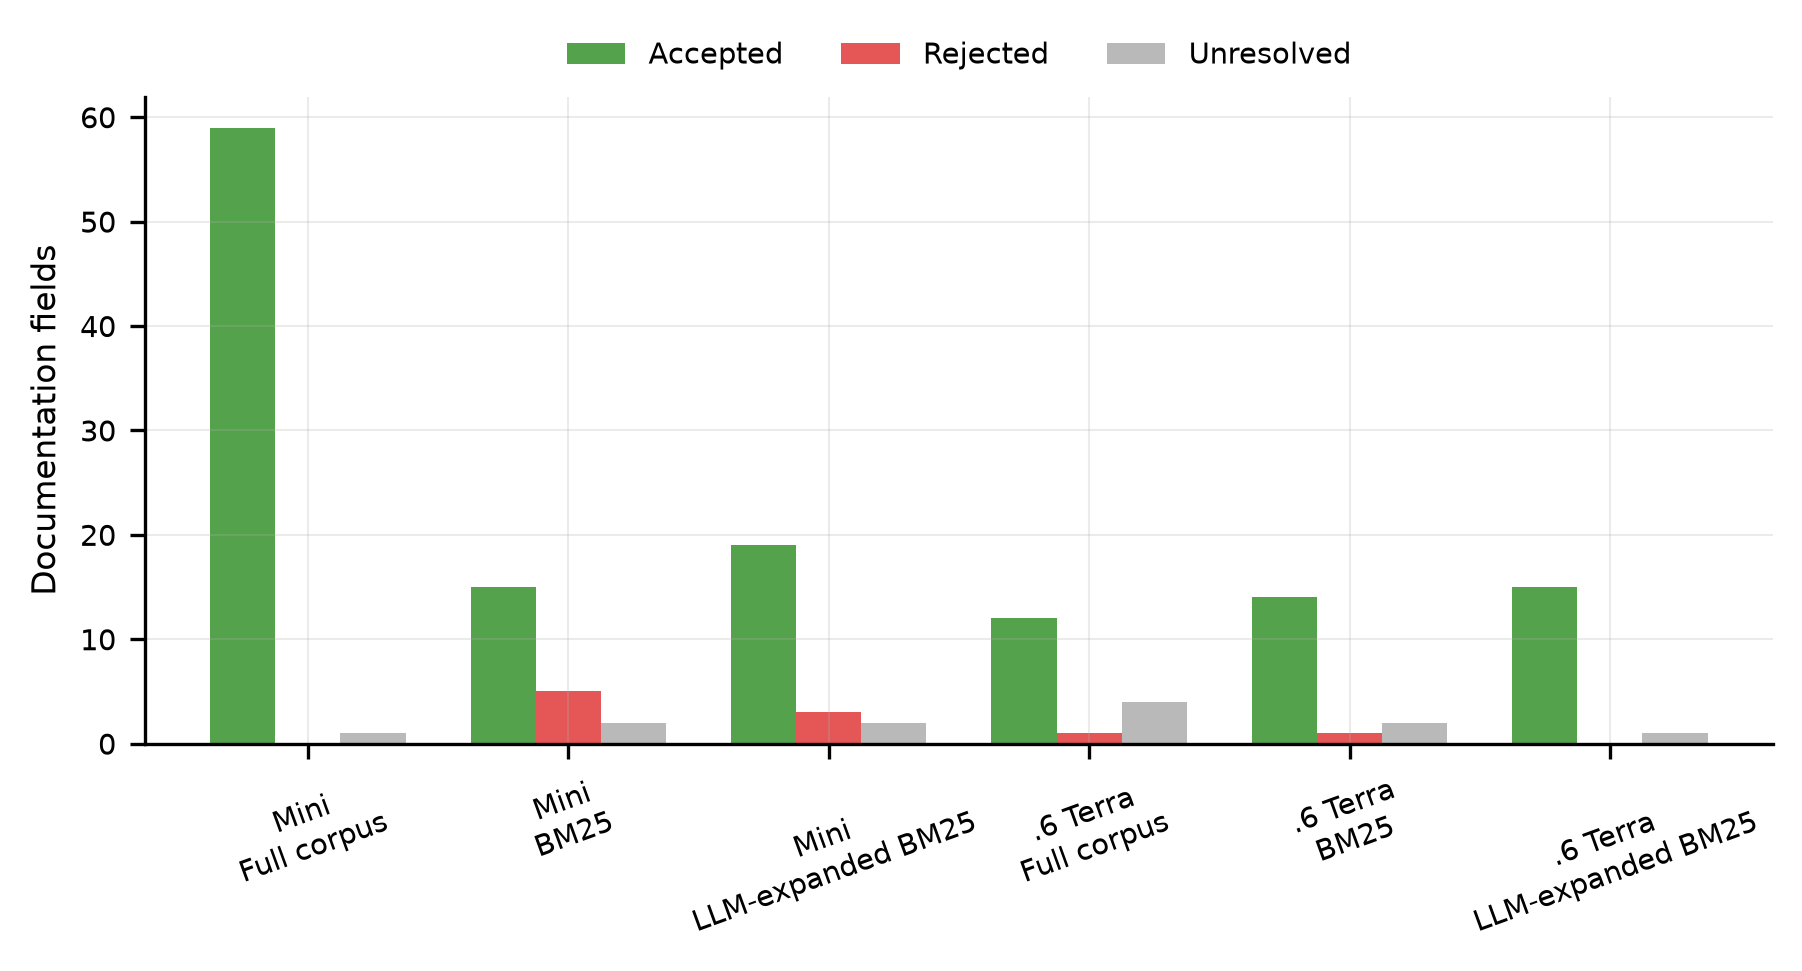

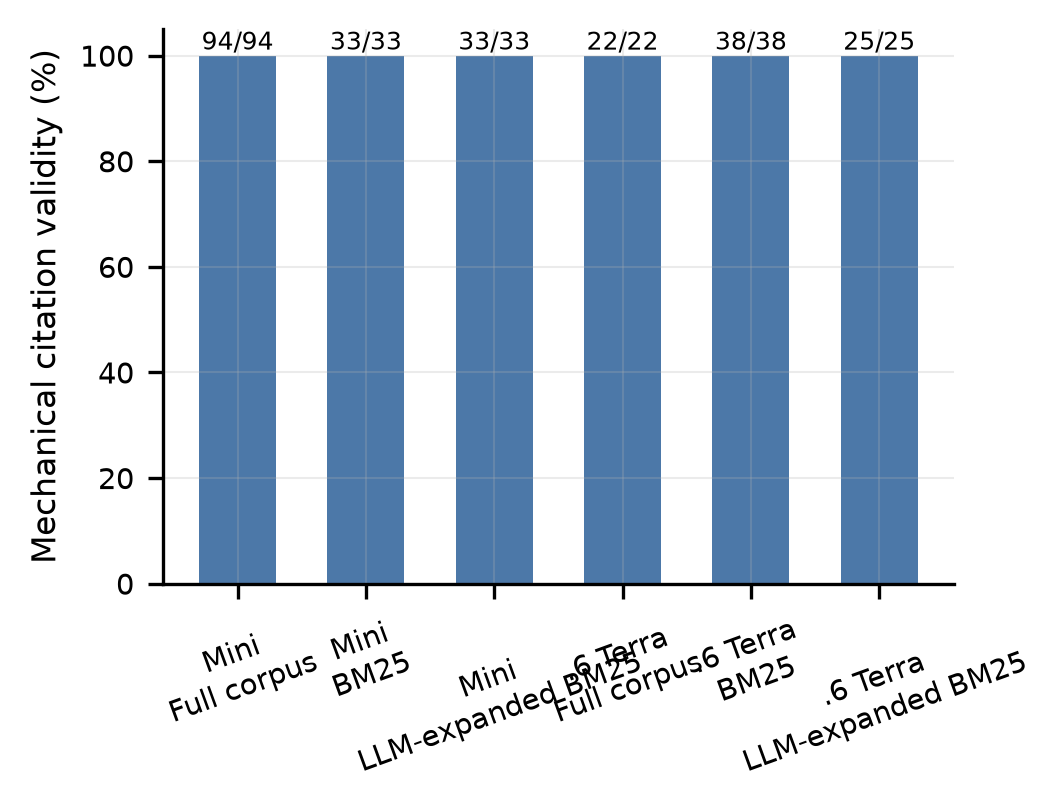

Rejected proposals per configuration: [0, 5, 3, 1, 1, 0]


In [16]:
# Split into two figures: extraction outcomes (field counts) and citation
# validity (a rate over citations). These answer different questions and were
# previously conflated by floating a citation percentage over field-count bars.

# --- Figure A: extraction outcomes per configuration ---
fig, ax = plt.subplots(figsize=(COL_2, 2.8))
doc_plot = documentation_df.set_index(["model", "mode"])[
    ["accepted_findings", "rejected_proposals", "unresolved_documentation_fields"]]
doc_plot.index = labels
doc_plot.plot(kind="bar", ax=ax, color=["#54A24B", "#E45756", "#B9B9B9"], width=0.75)
ax.set_ylabel("Documentation fields")
ax.tick_params(axis="x", rotation=20)
ax.legend(["Accepted", "Rejected", "Unresolved"], frameon=False, ncol=3,
          loc="lower center", bbox_to_anchor=(0.5, 1.0))
save(fig, "documentation-outcomes")

# --- Figure B: mechanical citation validity per configuration ---
fig, ax = plt.subplots(figsize=(COL_1, 2.4))
validity = documentation_df["mechanical_citation_validity"] * 100
bars = ax.bar(labels, validity, color="#4C78A8", width=0.6)
for b, r in zip(bars, documentation_df.itertuples()):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
            f"{r.valid_citations}/{r.citations}", ha="center", va="bottom", fontsize=6)
ax.set_ylabel("Mechanical citation validity (%)")
ax.set_ylim(0, 105)
ax.tick_params(axis="x", rotation=20)
save(fig, "citation-validity")

# Sanity: is the validator actually firing? If rejected is ~0 everywhere, the
# validator has not been shown to catch anything on this input.
print("Rejected proposals per configuration:",
      documentation_df["rejected_proposals"].tolist())
if documentation_df["rejected_proposals"].sum() == 0:
    print("WARNING: no proposals were rejected in any run. The validator did not "
          "fire on this input, so these runs do not demonstrate that it catches errors.")